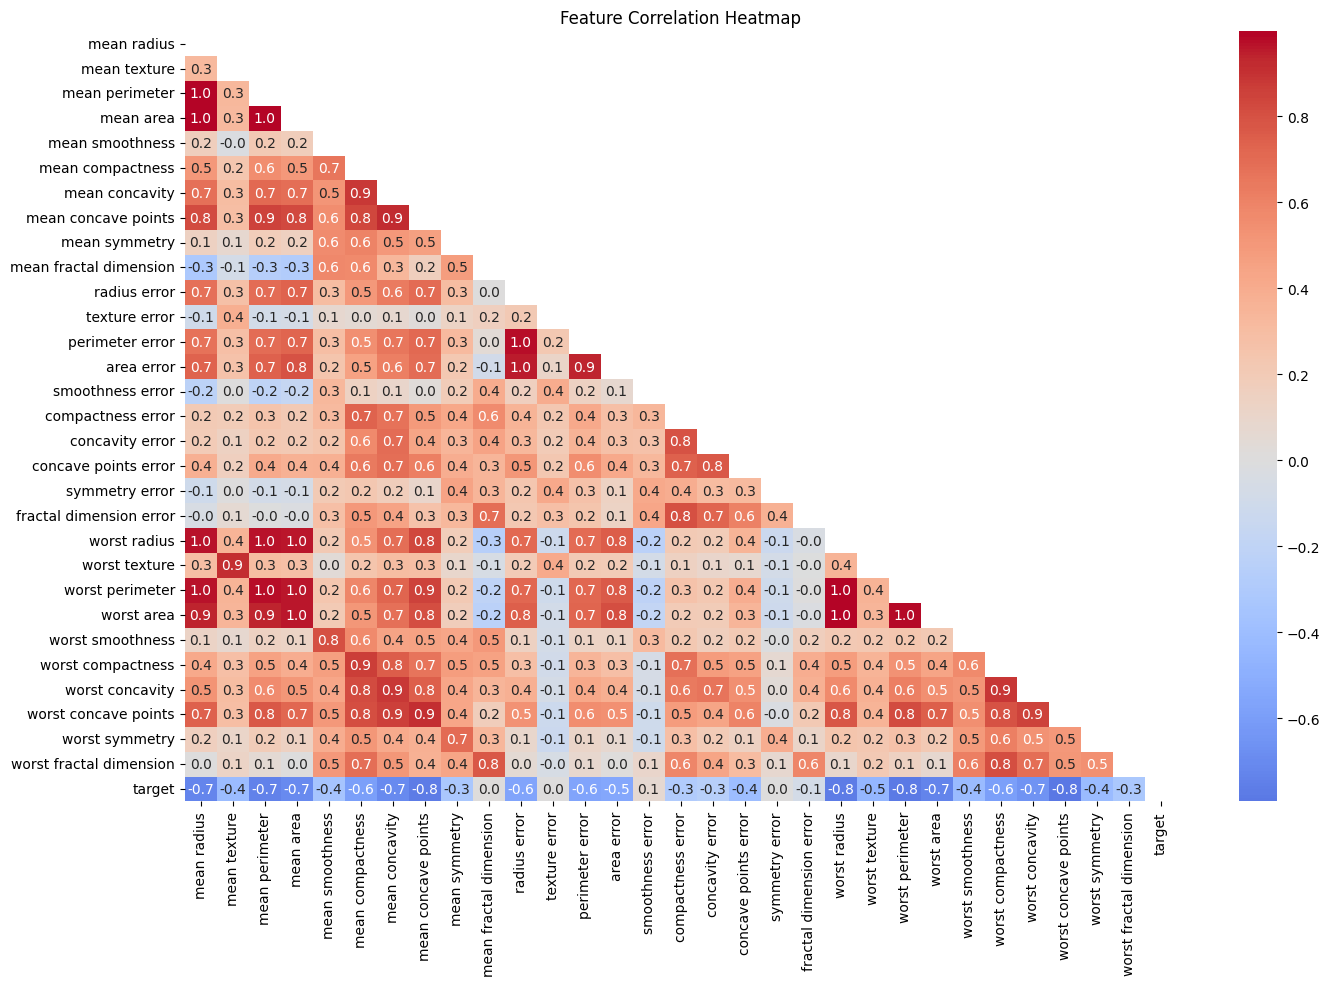

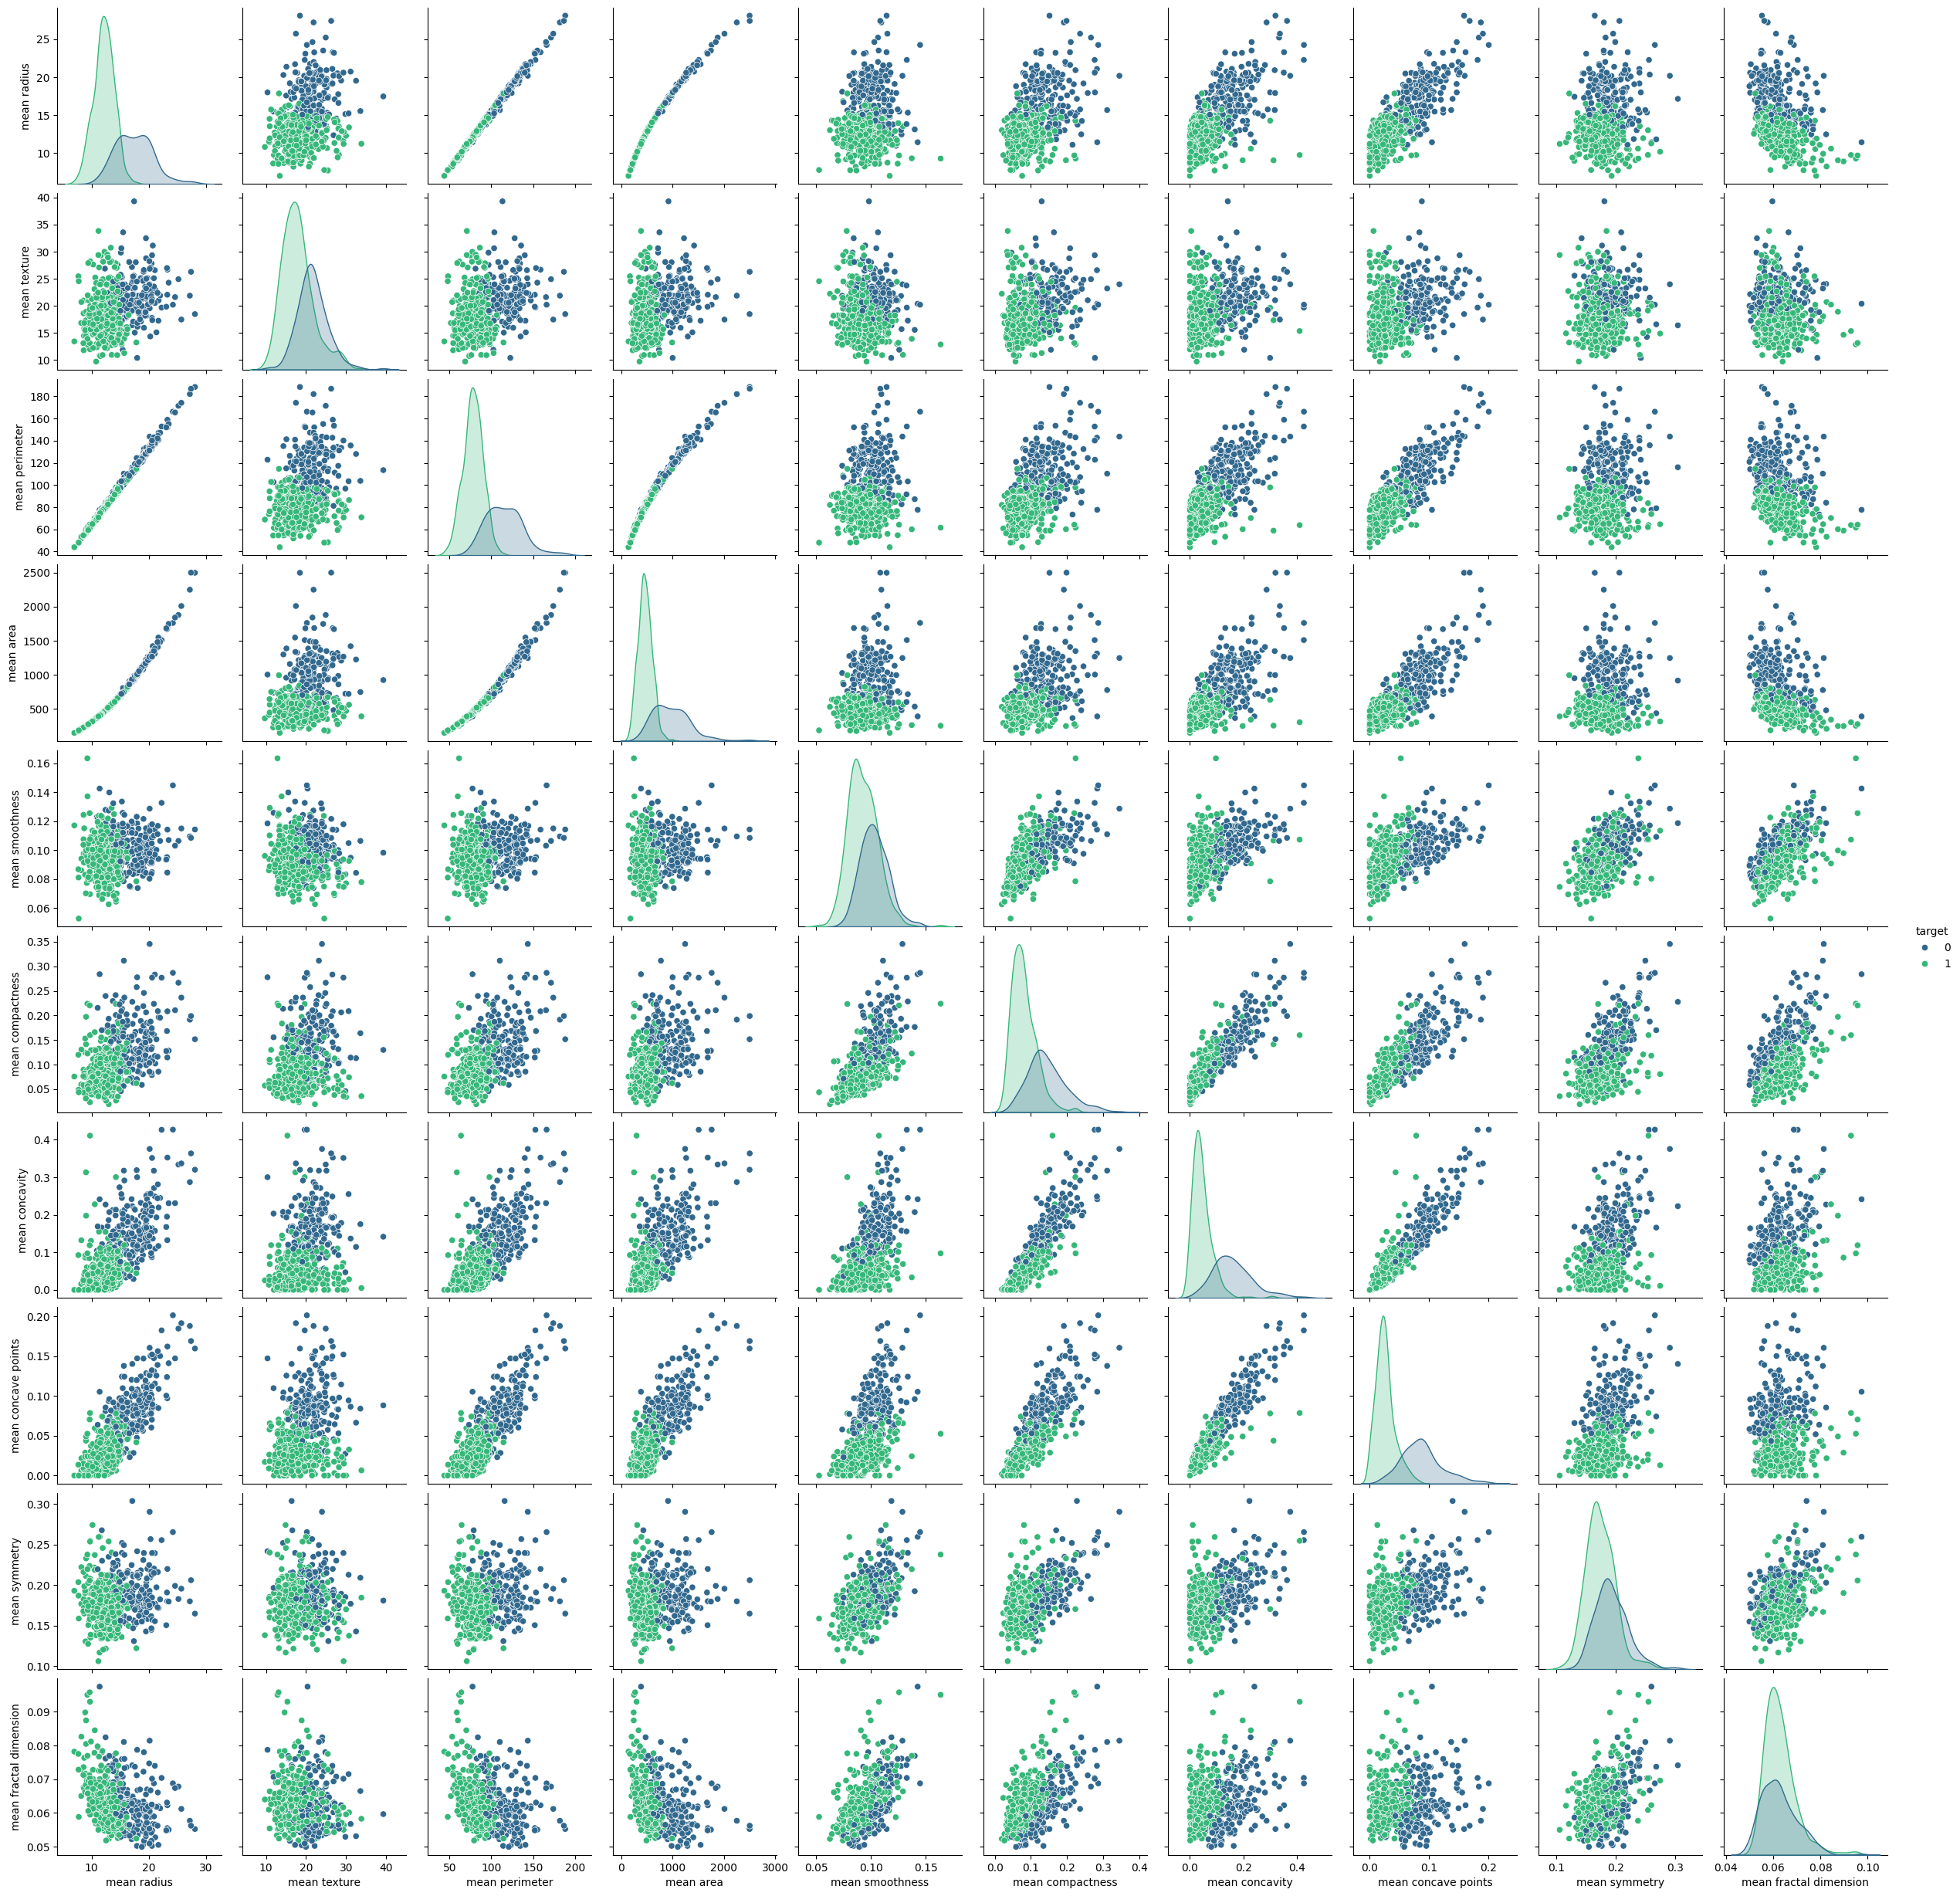

Strongest Positive Correlations:
 mean radius      mean perimeter     0.997855
mean perimeter   mean radius        0.997855
worst perimeter  worst radius       0.993708
worst radius     worst perimeter    0.993708
mean radius      mean area          0.987357
mean area        mean radius        0.987357
dtype: float64

Strongest Negative Correlations:
 mean concave points   target                 -0.776614
target                mean concave points    -0.776614
                      worst perimeter        -0.782914
worst perimeter       target                 -0.782914
worst concave points  target                 -0.793566
target                worst concave points   -0.793566
dtype: float64


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Load Data
df = pd.read_csv('breast_cancer_dataset.csv')

# 2. Compute Pearson Correlations
corr_matrix = df.corr()

# 3. Visualize as Heatmap
plt.figure(figsize=(16, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".1f", cmap='coolwarm', center=0)
plt.title('Feature Correlation Heatmap')
plt.show()

# 4. Pairplots for Key Variables (Mean Features)
mean_cols = [col for col in df.columns if 'mean' in col] + ['target']
sns.pairplot(df[mean_cols], hue='target', palette='viridis')
plt.show()

# 5. Summary of Relationships
corr_unstacked = corr_matrix.unstack().sort_values(ascending=False)
corr_unstacked = corr_unstacked[corr_unstacked < 1] # Remove self-correlations

print("Strongest Positive Correlations:\n", corr_unstacked.head(6))
print("\nStrongest Negative Correlations:\n", corr_unstacked.tail(6))